### Middaleware

Middaleware provides a way to more tightly control what happens inside the agent. Middleware is usefull for the following: 

- Tracking agent behavior with logging, analitics, and debugging.
- Transforming prompts, tool section, and output formating.
- Adding retries, fallbacks, and early termination logic.
- Applying rate limits, guardrails, and PII detection

In [1]:
import os
from dotenv import load_dotenv, find_dotenv
from langchain.chat_models import init_chat_model

# Load environment variables from .env
load_dotenv(find_dotenv(), override=True)

# Initialize Groq chat model
model = init_chat_model("groq:qwen/qwen3.8-27b",  max_tokens=500)
model

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.1', 'langchain': '1.3.18'}}, client=<groq.resources.chat.completions.Completions object at 0x000002B78D1D04F0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002B78D19FEB0>, model_name='qwen/qwen3.8-27b', model_kwargs={}, groq_api_key=SecretStr('**********'), max_tokens=500)

## Summarization Middleware 

Automaticaly summarise conversation history when approching token limits, preserving recent messages while compressing older context. Summarization is usefull for the following:

- Long-Running conversation that exceed context windows.
- Multi-turn dialogueswith extensive history.
- Application where preserving full conversation context matters.

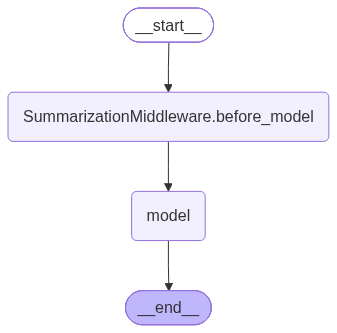

In [2]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import SystemMessage, HumanMessage

## Agent with Messagebased summurization

agent=create_agent(
    model,
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model,
            trigger=("messages",10),
            keep=("messages",4)
        )
    ]
)
agent

In [3]:
## Thread id

config={"configurable": {"thread_id": "test1"}}

In [4]:
# Alternative test Data

questions=[
    "What is 2+2?",
    "What is 10*5?",
    "What is 100/4?",
    "What is 15-7?",
    "What is 3*3?",
    "What is 4*4?"
]

for q in questions:
    response=agent.invoke({"messages": [HumanMessage(content=q)]},config=config)
    print(f"Message: {response}")
    print(f"Message: {len(response['messages'])}")

Message: {'messages': [HumanMessage(content='What is 2+2?', additional_kwargs={}, response_metadata={}, id='6042e968-a900-42ed-963a-6a867752b229'), AIMessage(content='2 + 2 = 4', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 19, 'total_tokens': 27, 'completion_time': 0.015452065, 'completion_tokens_details': None, 'prompt_time': 0.001088063, 'prompt_tokens_details': None, 'queue_time': 0.048758653, 'total_time': 0.016540128}, 'model_name': 'qwen/qwen3.8-27b', 'system_fingerprint': 'fp_a1293f40b5', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a107ee-a506-7611-b663-c708108b1056-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 19, 'output_tokens': 8, 'total_tokens': 27})]}
Message: 2
Message: {'messages': [HumanMessage(content='What is 2+2?', additional_kwargs={}, response_metadata={}, id='6042e968-a900-42ed-963a-6a867752b229'), AIMessage(content

## Token Size

In [5]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_core.tools import tool

@tool
def search_hotels(city: str) -> str:
    """Search Hotels - returns long response to use more token."""
    return f"""Hotel in {city}: 
    1. Grand Hotel - 5 star, $350/night, spa, pool, gym
    2. City Inn - 4 Star, $180/night, bussiness center
    3. Budget Stay - 3 Star, $75/night, free wify
    """

agent=create_agent(
    model,
    tools=[search_hotels],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model,
            trigger=("tokens",55),
            keep=("tokens", 200)
        )
    ]
)

config={"configurable": {"thread_id": "test1"}}

# Token counter (approximate)
def count_token(messages):
    total_chars=sum(len(str(m.content)) for m in messages)
    return total_chars // 4 # 4 chars= 1 token

In [6]:
# Run test 
cities= ["Paris", "Landon", "Tokyo", "New york", "Dubai", "Singapore"]

for city in cities:
    response= agent.invoke(
        {"messages": [HumanMessage(content=f"Find Hotels in {city}")]},
        config=config
    )
    token=count_token(response["messages"])
    print(f"{city}: ~{token} tokens, {len(response['messages'])} messages")
    print(f"{(response['messages'])}")

Paris: ~132 tokens, 4 messages
[HumanMessage(content='Find Hotels in Paris', additional_kwargs={}, response_metadata={}, id='01a19fd2-ae87-4632-a4f6-a53ac912458a'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'yv2tbdj4m', 'function': {'arguments': '{"city":"Paris"}', 'name': 'search_hotels'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 279, 'total_tokens': 306, 'completion_time': 0.06959391, 'completion_tokens_details': None, 'prompt_time': 0.019877267, 'prompt_tokens_details': None, 'queue_time': 0.053197835, 'total_time': 0.089471177}, 'model_name': 'qwen/qwen3.8-27b', 'system_fingerprint': 'fp_a1293f40b5', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a107ee-aa12-7152-aeec-d91114e0dad5-0', tool_calls=[{'name': 'search_hotels', 'args': {'city': 'Paris'}, 'id': 'yv2tbdj4m', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'inp

## Fraction

In [7]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_core.tools import tool

@tool
def search_hotels(city: str) -> str:
    """Search Hotels - returns long response to use more token."""
    return f"""Hotel in {city}: 
    1. Grand Hotel - 5 star, $350/night, spa, pool, gym
    2. City Inn - 4 Star, $180/night, bussiness center
    3. Budget Stay - 3 Star, $75/night, free wify
    """

agent=create_agent(
    model,
    tools=[search_hotels],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model,
            trigger=("fraction",0.005),
            keep=("fraction", 0.002)
        )
    ]
)

config={"configurable": {"thread_id": "test-1"}}

# Token counter (approximate)
def count_token(messages):
    total_chars=sum(len(str(m.content)) for m in messages)
    return total_chars // 4 # 4 chars= 1 token




# Run test 
cities= ["Paris", "Landon", "Tokyo", "New york", "Dubai", "Singapore"]

for city in cities:
    response= agent.invoke(
        {"messages": [HumanMessage(content=f"Find Hotels in {city}")]},
        config=config
    )
    token=count_token(response["messages"])
    fraction=token / 128000
    print(f"{city}: ~{token} tokens ({fraction: .4%}), {len(response['messages'])} messages")
    print(f"{(response['messages'])}")

ValueError: Model profile information is required to use fractional token limits, and is unavailable for the specified model. Please use absolute token counts instead, or pass `

ChatModel(..., profile={"max_input_tokens": ...})`.

with a desired integer value of the model's maximum input tokens.

## Human in the loop middleware

Pause agent execution for human approval, editing, or rejection of tool calls before they execute. Human-in-the-loop is usefull for the following:

- High-stakes operations requring human approval (e.g database writes, finacial transections).
- Compliance workflows where human oversight is mandatory.
- Long-running conversation where human feedback guides the agent.

In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver

def read_model_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email Content for ID: {email_id}"


def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

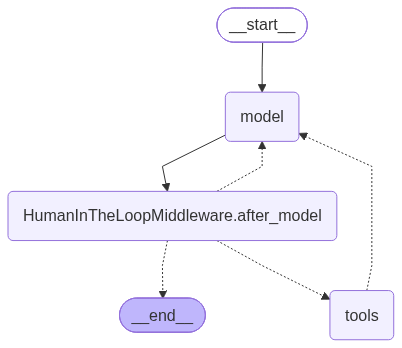

In [ ]:
from langchain import tools
agent=create_agent(
    model,
    tools=[read_model_tool, send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool":{
                    "allowed_decisions": ["approve", "edit", "reject"]
                },
                "read_model_tool": False
            }
        )
    ]
)
agent

## Approve

In [ ]:
config={"configurable": {"thread_id": "test-approve"}}
result=agent.invoke(
    {"messages": [HumanMessage(content="Send email to rps85071@gmail.com with subject 'Hello' and body 'How are you?'")]},
    config=config
)

In [ ]:
result

{'messages': [HumanMessage(content="Send email to rps85071@gmail.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='0c325233-ce0d-4534-a122-1d87ad012a23'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'a277rj0fe', 'function': {'arguments': '{"body":"How are you?","recipient":"rps85071@gmail.com","subject":"Hello"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 63, 'prompt_tokens': 382, 'total_tokens': 445, 'completion_time': 0.197025731, 'completion_tokens_details': None, 'prompt_time': 0.027904081, 'prompt_tokens_details': None, 'queue_time': 0.048576277, 'total_time': 0.224929812}, 'model_name': 'qwen/qwen3.8-27b', 'system_fingerprint': 'fp_424cb89518', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0ee77-9b92-7cc1-926d-66ea34fb5e03-0', tool_calls=[{'name': 'send_email_tool', 'args': 

In [ ]:
from langgraph.types import Command
## step 1 : approve

if "__interrupt__" in result:
    print("Approving")

    result=agent.invoke(
        Command(
            resume={
                "decisions": [
                    {"type":"approve"}
                ]
            }
        ),
        config=config
    )

    print(f"Result: {result['messages'][-1].content}")

Approving
Result: ✅ Email sent successfully to rps85071@gmail.com with subject "Hello" and body "How are you?"


## Reject

In [ ]:
config={"configurable": {"thread_id": "test-reject"}}
result=agent.invoke(
    {"messages": [HumanMessage(content="Send email to rps85071@gmail.com with subject 'Hello' and body 'How are you?'")]},
    config=config
)

In [ ]:
from langgraph.types import Command
## step 1 : approve

if "__interrupt__" in result:
    print("Paused! Approving...")

    result=agent.invoke(
        Command(
            resume={
                "decisions": [
                    {"type":"reject"}
                ]
            }
        ),
        config=config
    )

    print(f"Result: {result['messages'][-1].content}")

Paused! Approving...
Result: The email wasn't sent because the tool call was rejected. Let me know if you'd like me to try again or make any changes to the message.


## Edit

In [ ]:
config={"configurable": {"thread_id": "test-edit"}}
result=agent.invoke(
    {"messages": [HumanMessage(content="Send email to rps85071@gmail.com with subject 'Hello' and body 'How are you?'")]},
    config=config
)

In [ ]:
from langgraph.types import Command
## step 1 : approve

if "__interrupt__" in result:
    print("Editing...")

    result=agent.invoke(
        Command(
            resume={
                "decisions": [
                    {
                        "type":"edit",
                        "edited_action":{
                            "name": "send_email_tool",
                            "args": {
                                "recipient": "correct@gmail.com",
                                "subject": "Corrected Subject",
                                "body": "This was edited by human before sending"
                            }
                        }
                    }
                    
                ]
            }
        ),
        config=config
    )

    print(f"Result: {result['messages'][-1].content}")

Editing...


KeyError: 'edited_action'

In [ ]:
from langgraph.types import Command

## step 2 : edit
if "__interrupt__" in result:
    print("Editing and Resuming...")

    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {
                        "type": "edit",
                        "edited_action": {
                            "name": "send_email_tool",
                            "args": {
                                "recipient": "correct@gmail.com",
                                "subject": "Corrected Subject",
                                "body": "This was edited by human before sending"
                            }
                        }
                    }
                ]
            }
        ),
        config=config
    )

    if "messages" in result and result["messages"]:
        print(f"Result: {result['messages'][-1].content}")


Editing and Resuming...


KeyError: 'edited_action'